In [1]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load integrated_data for exploratory data analysis of new variables
integrated_data = pd.read_csv("integrated_data.csv")

C:\Users\vgmay\AppData\Local\Temp\ipykernel_11492\1417382761.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  integrated_data = pd.read_csv("integrated_data.csv")


In [3]:
print(integrated_data.columns)

Index(['Unnamed: 0', 'Year', 'Person.ID', 'Drug', 'Quantity', 'Form',
       'Strength', 'Day_Supply', 'Sum.of.all.payments', 'Administration_route',
       'Daily_Frequency', 'Daily_Dosage', 'Age', 'Sex', 'Ethnicity', 'Race',
       'Personal_income', 'Family_income', 'Poverty_category',
       'Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage',
       'Concentration', 'Concentration_Level', 'Vet_drug', 'OTC_drug',
       'Abuse_potential'],
      dtype='object')


In [4]:
# remove rows with Inf (had division by zero due to unexpected zeros)
integrated_data = integrated_data[~integrated_data.isin([np.inf, -np.inf]).any(axis=1)]

In [5]:
# plot daily dosage per year for 2014, 2016, 2018, 2020-2022 for subset of drugs related to COVID-19
filtered_drugs = ['ibuprofen', 'dextromethorphan', 'hydroxychloroquine', 'acetaminophen', 'diphenhydramine']
filtered_data = integrated_data[integrated_data['Drug'].isin(filtered_drugs)]
daily_dosage_per_year = filtered_data.groupby('Year')['Daily_Dosage'].mean()


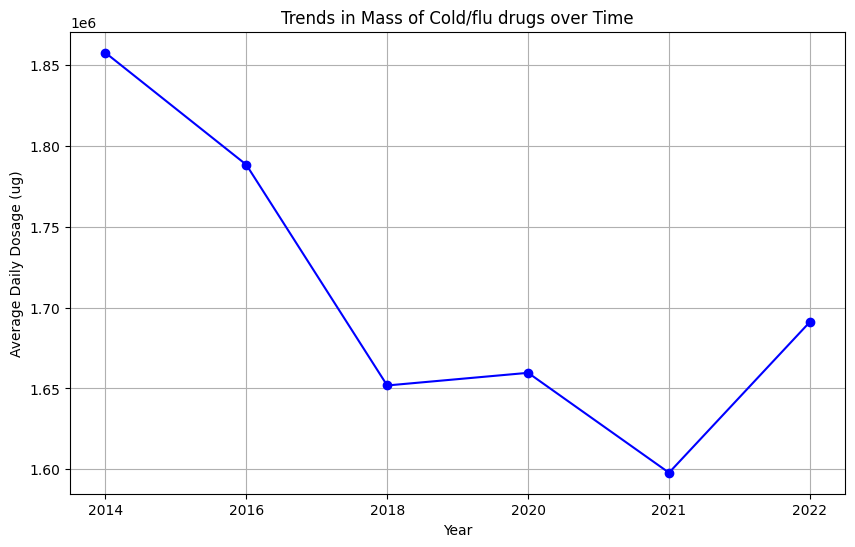

In [7]:
plt.figure(figsize=(10, 6))
plt.plot( daily_dosage_per_year.values, marker='o', linestyle='-', color='b')

# Setting labels and title
ticks = [0, 1, 2,3,4,5]  
labels = ['2014', '2016', '2018','2020','2021','2022']  
plt.xticks(ticks, labels)
plt.xlabel('Year')
plt.ylabel('Average Daily Dosage (ug)')
plt.title('Trends in Mass of Cold/flu drugs over Time')
plt.grid(True)

plt.show()

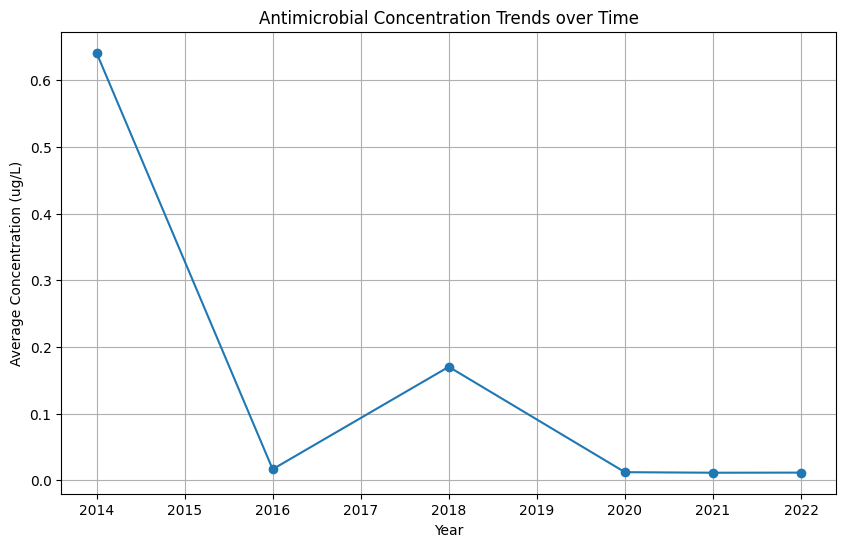

In [17]:
# trends in top antibiotics (according to Drugs.com) over time (plot average antibiotic concentration over time for these drugs)
antibiotics = ['amoxicillin','doxycycline','cephalexin','ciprofloxacin','clindamycin',
               'metronidazole','azithromycin','sulfamethoxazole','trimethoprim','clavulanate',
               'levofloxacin']

antibiotics_data = integrated_data[integrated_data['Drug'].isin(antibiotics)]
antibiotics_data = antibiotics_data.groupby('Year', as_index=False)['Concentration'].mean()

# create plot
plt.figure(figsize=(10, 6))
plt.plot(antibiotics_data['Year'], antibiotics_data['Concentration'], marker='o')

plt.xlabel('Year')
plt.ylabel('Average Concentration (ug/L)')
plt.title('Antimicrobial Concentration Trends over Time')

plt.grid(True)
plt.show()


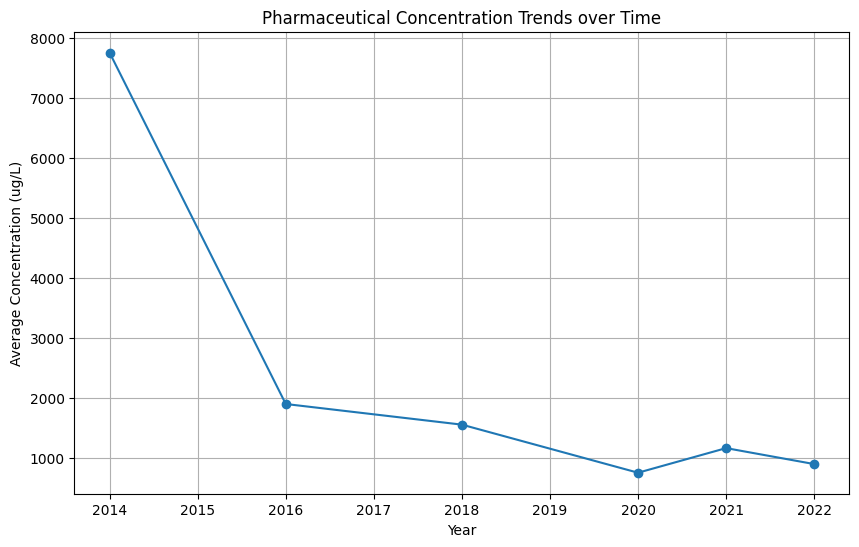

In [20]:
# overall concentrations over time (summed by year)
integ_data_yearly = integrated_data.groupby('Year', as_index=False)['Concentration'].sum()

# create plot
plt.figure(figsize=(10, 6))
plt.plot(integ_data_yearly['Year'], integ_data_yearly['Concentration'], marker='o')

plt.xlabel('Year')
plt.ylabel('Average Concentration (ug/L)')
plt.title('Pharmaceutical Concentration Trends over Time')

plt.grid(True)
plt.show()

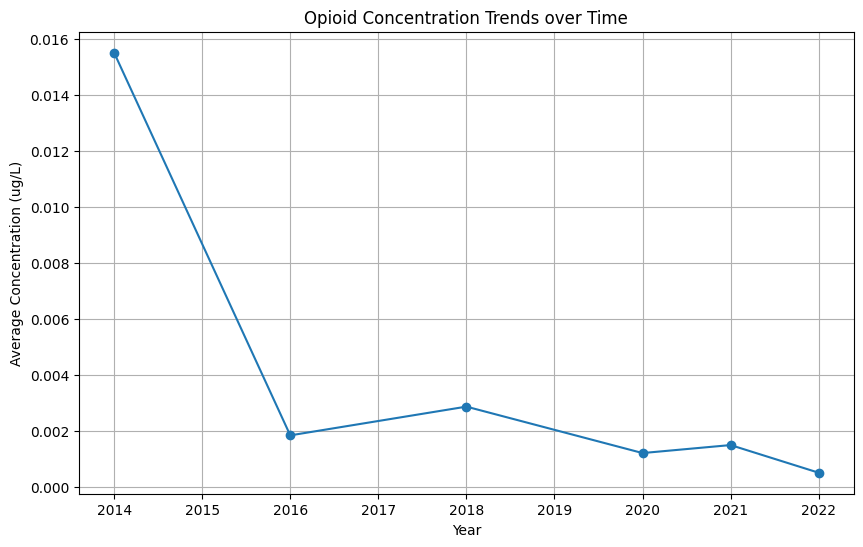

In [21]:
# opioid concentrations (using most common opioids per Office of Addiction Services and Supports) - plot avg concentration of opioids over time
opioids = ['oxycodone','morphine','hydrocodone','hydromorphone','meperidine','codeine','fentanyl']

opioid_data = integrated_data[integrated_data['Drug'].isin(opioids)]
opioid_data = opioid_data.groupby('Year', as_index=False)['Concentration'].mean()

# create plot
plt.figure(figsize=(10, 6))
plt.plot(opioid_data['Year'], opioid_data['Concentration'], marker='o')

plt.xlabel('Year')
plt.ylabel('Average Concentration (ug/L)')
plt.title('Opioid Concentration Trends over Time')

plt.grid(True)
plt.show()

In [7]:
# find mean of concentration
mean_conc = integrated_data['Concentration'].mean()
print("Mean concentration:", mean_conc)

Mean concentration: 0.008793234093573991


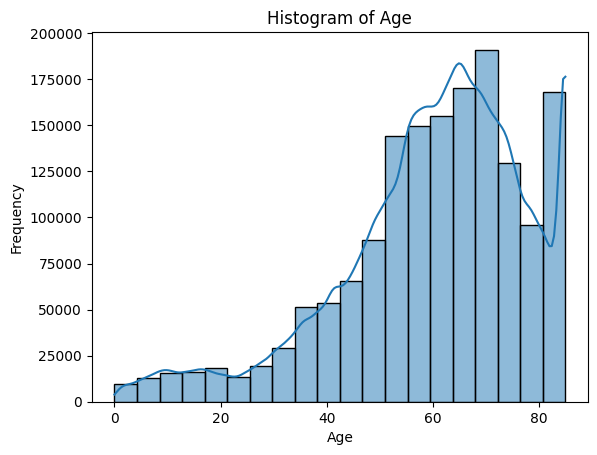

In [8]:
# plot age as histogram
sns.histplot(data=integrated_data, x='Age', bins=20, kde=True)
plt.xlabel('Age')  # Label for x-axis
plt.ylabel('Frequency')     # Label for y-axis
plt.title('Histogram of Age')  # Title
plt.show()

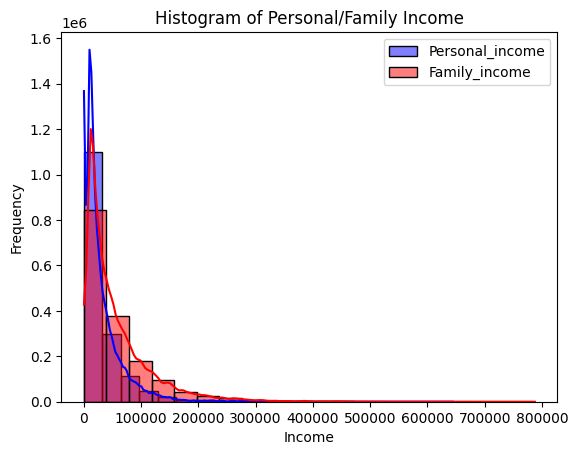

In [9]:
# plot personal and family income on histogram
sns.histplot(data=integrated_data, x='Personal_income', color='blue', bins=20, label='Personal_income', kde=True)
sns.histplot(data=integrated_data, x='Family_income', color='red', bins=20, label='Family_income', kde=True)

# Add labels and title
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Histogram of Personal/Family Income')
plt.legend()

plt.show()

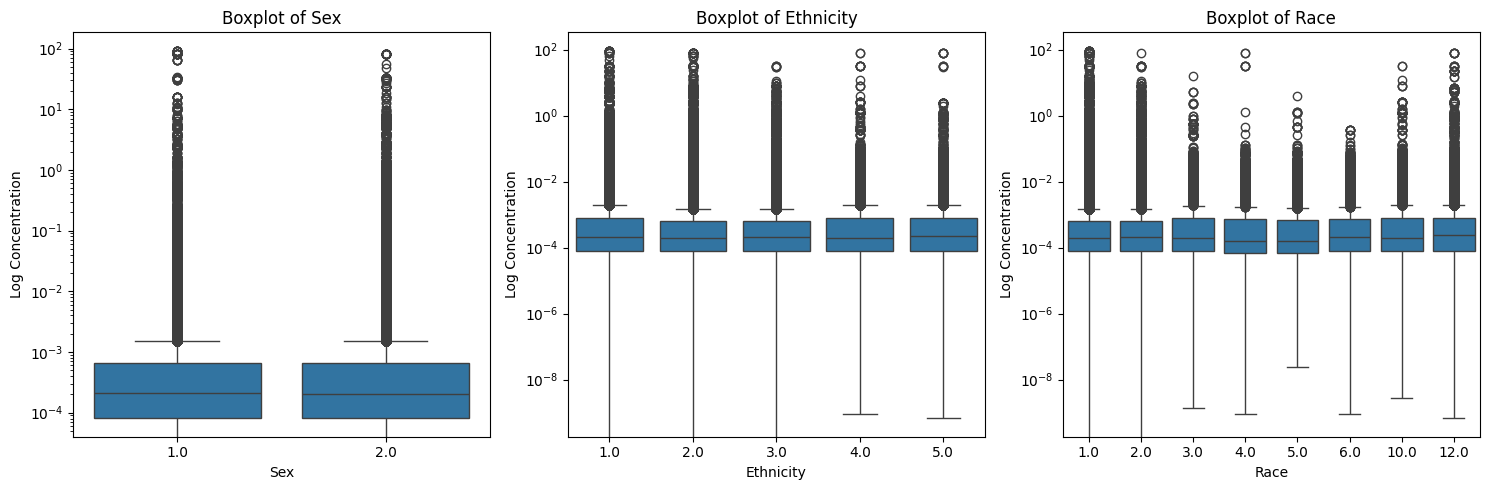

In [10]:
# boxplots for new categorical variables against concentration
categorical_columns = ['Sex', 'Ethnicity', 'Race']

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))

for i, cat_col in enumerate(categorical_columns):
    sns.boxplot(x=cat_col, y='Concentration', data=integrated_data, ax=axes[i])
    axes[i].set_title(f'Boxplot of {cat_col}')
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Log Concentration')

plt.tight_layout()
plt.show()

In [11]:
# remove nan from PMED_insurance_coverage
integrated_data = integrated_data.dropna(subset=['PMED_insurance_coverage'])
# then also assign values less than 1.5 to 1 and more than 1.5 to 2
integrated_data['PMED_insurance_coverage'] = np.where(integrated_data['PMED_insurance_coverage'] < 1.5, 1, 2)

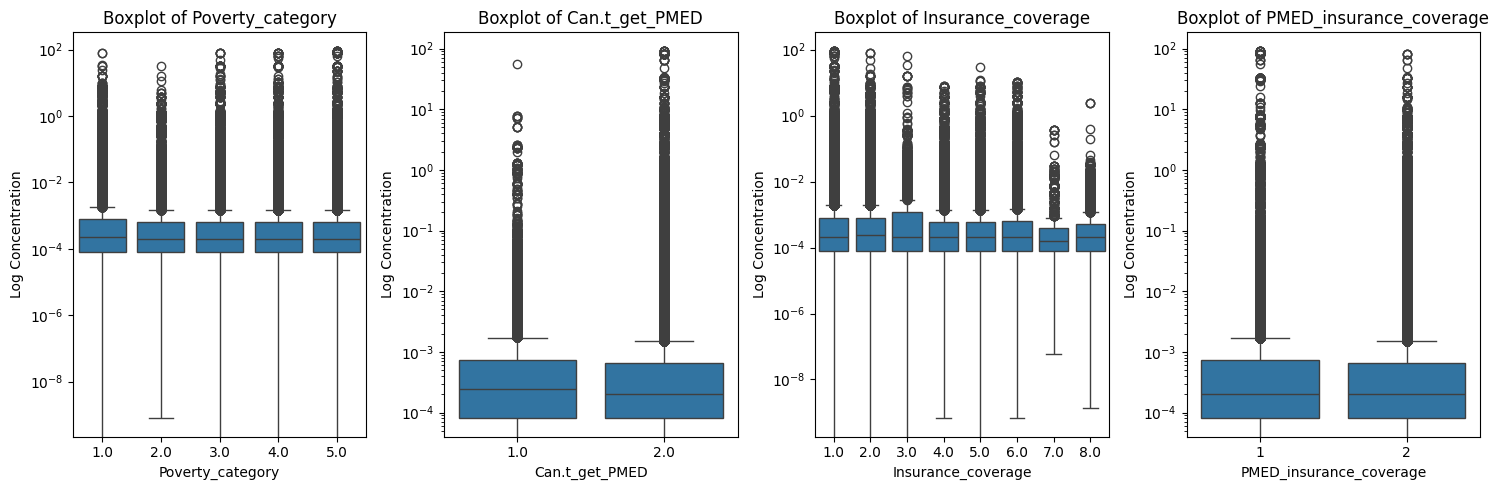

In [12]:
# boxplots for new categorical variables against concentration
categorical_columns = ['Poverty_category', 'Can.t_get_PMED', 'Insurance_coverage',
                       'PMED_insurance_coverage']

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(15, 5))

for i, cat_col in enumerate(categorical_columns):
    sns.boxplot(x=cat_col, y='Concentration', data=integrated_data, ax=axes[i])
    axes[i].set_title(f'Boxplot of {cat_col}')
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Log Concentration')

plt.tight_layout()
plt.show()

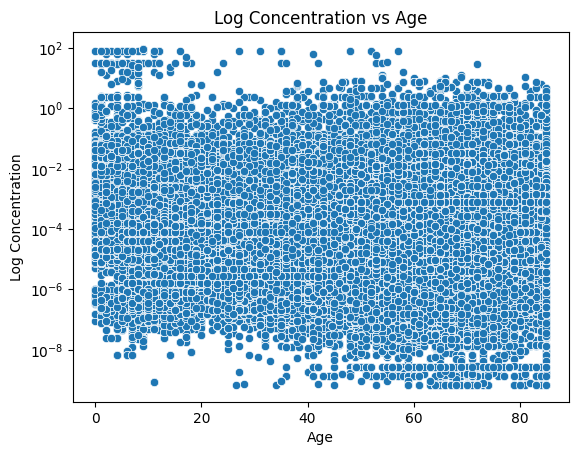

In [13]:
# relate age to concentration
sns.scatterplot(x='Age', y='Concentration', data=integrated_data)
plt.yscale('log')
plt.title('Log Concentration vs Age')
plt.ylabel('Log Concentration')
plt.show()

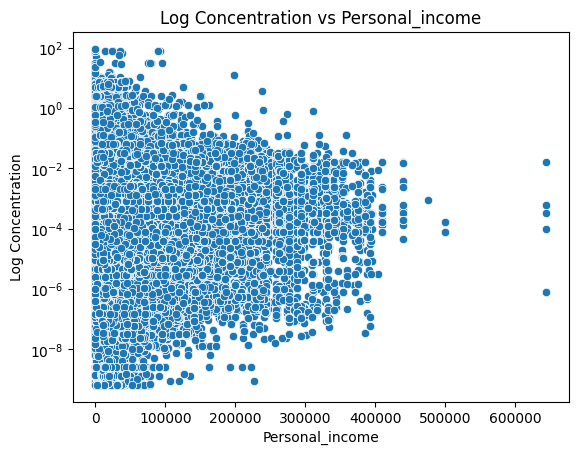

In [14]:
# relate personal income to concentration
sns.scatterplot(x='Personal_income', y='Concentration', data=integrated_data)
plt.yscale('log')
plt.title('Log Concentration vs Personal_income')
plt.ylabel('Log Concentration')
plt.show()

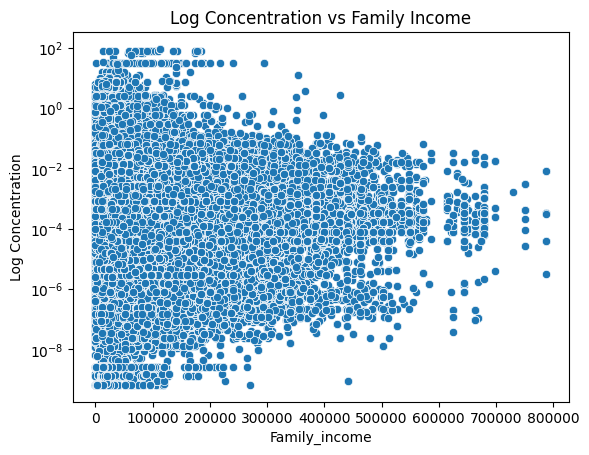

In [15]:
# relate family income to concentration
sns.scatterplot(x='Family_income', y='Concentration', data=integrated_data)
plt.yscale('log')
plt.title('Log Concentration vs Family Income')
plt.ylabel('Log Concentration')
plt.show()